In [41]:
import string
from dotenv import load_dotenv

import pandas as pd
import seaborn as sns
from transformers import AutoTokenizer
from huggingface_hub import login

from inference.evaluator import Evaluator

load_dotenv()
login()

In [10]:
from inference.utils.prompt_templates import (
    MC_QUESTION_TEMPLATE,
    MATH_TEMPLATE,
    TRANSLATION_TEMPLATE
)

In [11]:
def prepare_prompt(
    task_data: pd.Series,
    question_type: str
) -> str:
    """Chooses and fills a question template.

    The function first chooses the correct template based on the question type parameter
    and fills the template with the data from the task series.

    Args:
        task_data (pd.Series): Series containing the question and possibly answer options.
        question_type (str): String identifier of the question type.
            Can be 'mc', 'math' or 'translation'.

    Returns:
        str: The question template with filled placeholders.

    Raises:
        ValueError: If the question type is unknown.
    """
    if question_type == "mc":
        template = MC_QUESTION_TEMPLATE
    elif question_type == "math":
        template = MATH_TEMPLATE
    elif question_type == "translation":
        template = TRANSLATION_TEMPLATE
    else:
        raise ValueError(
            f"Invalid question type {question_type}. Must be 'mc', 'math' "
            f"or 'translation'.")

    prompt_kwargs = {"question": task_data["question"]}
    if question_type == "mc":
        letters = string.ascii_uppercase
        choices = "\n".join(
            f"({letters[i]}) {answer}"
            for i, answer in enumerate(task_data["answers"])
        )
        prompt_kwargs["choices"] = choices

    return template.format(**prompt_kwargs)

In [39]:
evaluator = Evaluator()
tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct"
)

length_df = pd.DataFrame()
for dataset_name, dataset_qt in [("mmlu-pro", "mc"), ("MATH", "math"), ("flores", "translation")]:
    _, dataset_df = evaluator.get_data(dataset_name)

    prompts = dataset_df.apply(
        prepare_prompt, axis=1, question_type=dataset_qt)

    prompts_tokenized = tokenizer(prompts.to_list())

    # calculate statistics
    dataset_lengths = {
        "dataset": [dataset_name for _ in prompts_tokenized["input_ids"]],
        "length": [len(p) for p in prompts_tokenized["input_ids"]]
    }
    dataset_lengths = pd.DataFrame(dataset_lengths)
    length_df = pd.concat([length_df, dataset_lengths])

2026-01-28 09:08:42  INFO     dataset_handler:_load               Preparing datasets
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Loading mmlu-pro
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for category
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Dataframe length: 2800
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Loading MATH
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for subject
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Dataframe length: 500
2026-01-28 09:08:42  INFO     dataset_handler:_download_dataset   Loading flores
2026-01-28 09:08:43  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for iso_639_3
2026-01-28 09:08:43  INFO     dataset_handler:_download_dataset   Dataframe length: 41400


<Axes: xlabel='dataset', ylabel='length'>

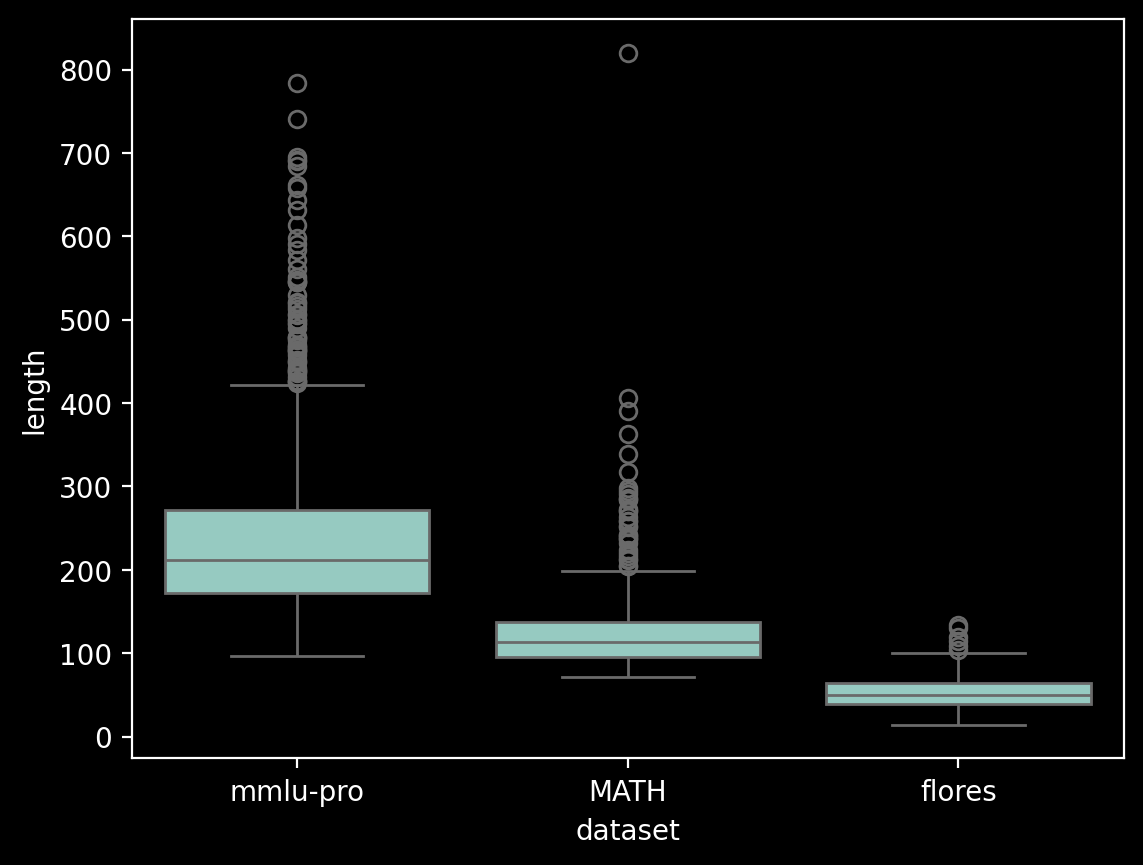

In [43]:
sns.boxplot(length_df, x="dataset", y="length")